# Overfitting, Underfitting & Regularization

This notebook walks through:

1. **Dataset splitting techniques**:  train/test, train/val/test, k-fold CV, stratified split
2. **Underfitting** and **overfitting** demonstrated on a toy regression dataset
3. Fixing overfitting with **Dropout**, **L2 regularization** (weight decay), and **L1 regularization**

Each section is runnable independently and builds on a small synthetic dataset so results are easy to see.

In [15]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

torch.manual_seed(0)
np.random.seed(0)

## 1. Dataset

We use a 1D regression problem: `y = sin(2x) + noise`. We deliberately keep the
training set **small** (40 points)

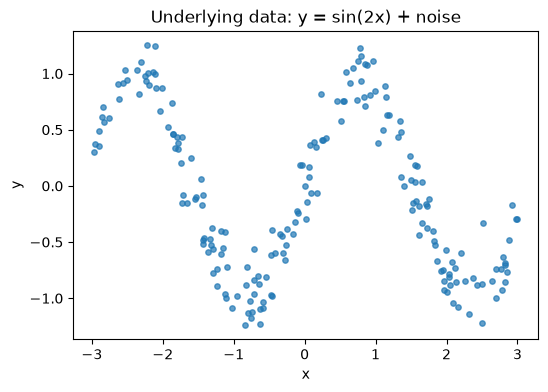

In [16]:
def make_dataset(n_samples=40, noise=0.2, x_range=(-3, 3), seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(*x_range, size=n_samples)
    y = np.sin(2 * x) + rng.normal(0, noise, size=n_samples)
    return x.astype(np.float32), y.astype(np.float32)

x_all, y_all = make_dataset(n_samples=200, seed=1)  # large pool to split from

plt.figure(figsize=(6, 4))
plt.scatter(x_all, y_all, s=15, alpha=0.7)
plt.title("Underlying data: y = sin(2x) + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2. Dataset split techniques

### 2.1 Simple train/test split
The most basic split: hold out a fraction of the data for testing.

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    x_all, y_all, test_size=0.2, random_state=42
)
print(f"train: {len(x_train)}, test: {len(x_test)}")

train: 160, test: 40


### 2.2 Train / validation / test split
In practice we also need a **validation** set to tune hyperparameters (and to
watch for overfitting during training) without touching the test set.

In [18]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x_all, y_all, test_size=0.4, random_state=42
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
)
print(f"train: {len(x_train)}, val: {len(x_val)}, test: {len(x_test)}")

train: 120, val: 40, test: 40


### 2.3 K-Fold cross-validation
Instead of a single split, k-fold CV rotates which chunk of data is held out,
giving a more robust estimate of generalization performance on small datasets.

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(x_all)):
    print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

Fold 0: train=160, val=40
Fold 1: train=160, val=40
Fold 2: train=160, val=40
Fold 3: train=160, val=40
Fold 4: train=160, val=40


### 2.4 Stratified split (for classification)
When the target is categorical and classes are imbalanced, a plain random split
can produce folds with skewed class ratios. `StratifiedKFold` / `train_test_split(..., stratify=y)`
preserves the class proportions in every split. We only illustrate this on a
synthetic imbalanced label array — the rest of this notebook is a regression
problem, so it doesn't otherwise apply here.

In [20]:
y_classes = np.array([0] * 90 + [1] * 10)  # imbalanced: 90% vs 10%

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros_like(y_classes), y_classes)):
    val_ratio = y_classes[val_idx].mean()
    print(f"Fold {fold}: val class-1 ratio = {val_ratio:.2f} (overall = {y_classes.mean():.2f})")

Fold 0: val class-1 ratio = 0.12 (overall = 0.10)
Fold 1: val class-1 ratio = 0.09 (overall = 0.10)
Fold 2: val class-1 ratio = 0.09 (overall = 0.10)


We'll use the **train / validation** split from section 2.2 for the rest of
the notebook (`x_train`, `y_train`, `x_val`, `y_val`).

In [21]:
Xtr = torch.from_numpy(x_train).unsqueeze(1)
Ytr = torch.from_numpy(y_train).unsqueeze(1)
Xval = torch.from_numpy(x_val).unsqueeze(1)
Yval = torch.from_numpy(y_val).unsqueeze(1)

x_plot = np.linspace(-3, 3, 300).astype(np.float32)
X_plot = torch.from_numpy(x_plot).unsqueeze(1)

## 3. Training helper

A shared training loop so every experiment below (underfit, overfit, dropout,
L1, L2) is trained and compared the same way. It optionally adds an L1 penalty
on top of whatever loss/optimizer is passed in.

In [22]:
def train_model(model, epochs=300, lr=0.01, weight_decay=0.0, l1_lambda=0.0, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(Xtr)
        loss = criterion(pred, Ytr)

        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xval), Yval)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | train: {loss.item():.4f} | val: {val_loss.item():.4f}")

    return train_losses, val_losses


def plot_fit(model, title):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_plot).numpy().ravel()

    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, s=15, alpha=0.6, label="train")
    plt.scatter(x_val, y_val, s=15, alpha=0.6, label="val")
    plt.plot(x_plot, y_pred, color="red", label="model")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

## 4. Underfitting

A model with **too little capacity** (a plain linear model, no hidden layers)
cannot represent the sine curve. Both train and validation loss stay high and
the fitted line is clearly a poor match — this is underfitting.

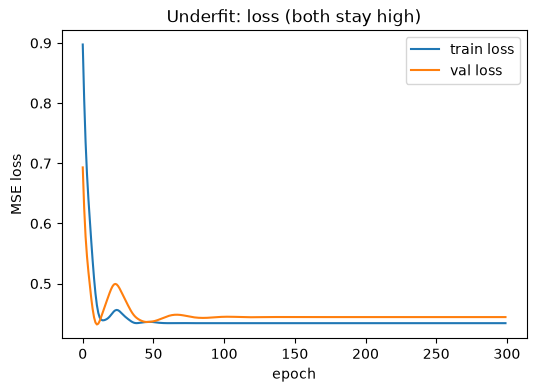

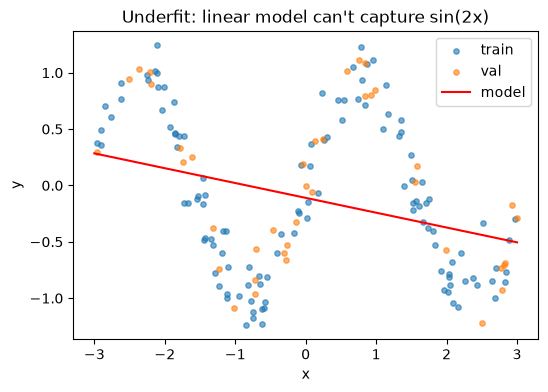

Final train loss: 0.4343 | val loss: 0.4444


In [23]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

underfit_model = LinearModel()
underfit_train, underfit_val = train_model(underfit_model, epochs=300, lr=0.05)

plot_losses(underfit_train, underfit_val, "Underfit: loss (both stay high)")
plot_fit(underfit_model, "Underfit: linear model can't capture sin(2x)")
print(f"Final train loss: {underfit_train[-1]:.4f} | val loss: {underfit_val[-1]:.4f}")

## 5. Overfitting

Now the opposite problem: a **high-capacity** network (several wide hidden
layers) trained for many epochs on a **small** training set. It has enough
parameters to memorize the noise in the training data. Training loss keeps
dropping while validation loss plateaus or rises — the classic overfitting
signature — and the fitted curve becomes wiggly, chasing individual noisy
points instead of the underlying sine.

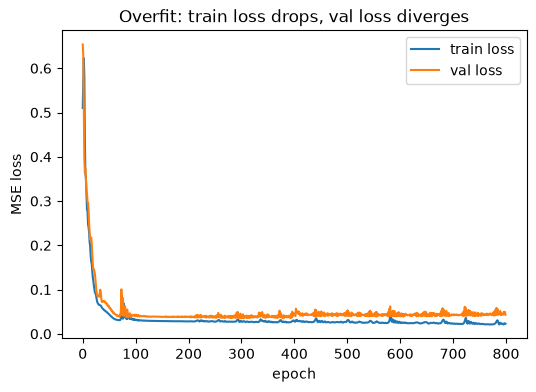

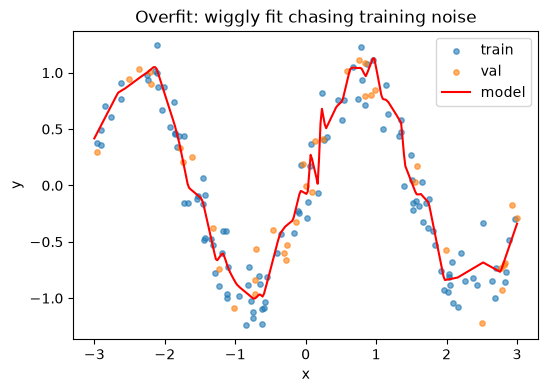

Final train loss: 0.0231 | val loss: 0.0431


In [24]:
class BigNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

overfit_model = BigNet()
overfit_train, overfit_val = train_model(overfit_model, epochs=800, lr=0.01)

plot_losses(overfit_train, overfit_val, "Overfit: train loss drops, val loss diverges")
plot_fit(overfit_model, "Overfit: wiggly fit chasing training noise")
print(f"Final train loss: {overfit_train[-1]:.4f} | val loss: {overfit_val[-1]:.4f}")

## 6. Fix #1 — Dropout

Dropout randomly zeroes a fraction of activations during training, preventing
the network from co-adapting to (and memorizing) specific training examples.
Same architecture and training budget as the overfitting example above, just
with `nn.Dropout` layers added.

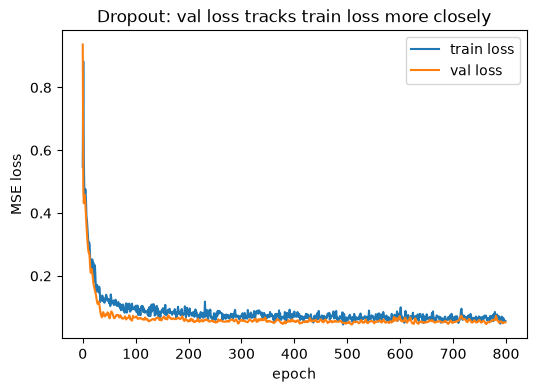

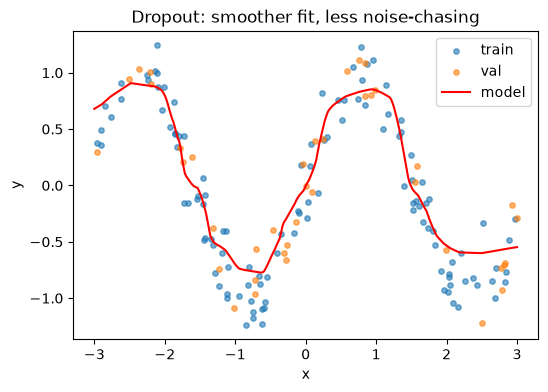

Final train loss: 0.0559 | val loss: 0.0524


In [25]:
class DropoutNet(nn.Module):
    def __init__(self, hidden=128, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

dropout_model = DropoutNet()
dropout_train, dropout_val = train_model(dropout_model, epochs=800, lr=0.01)

plot_losses(dropout_train, dropout_val, "Dropout: val loss tracks train loss more closely")
plot_fit(dropout_model, "Dropout: smoother fit, less noise-chasing")
print(f"Final train loss: {dropout_train[-1]:.4f} | val loss: {dropout_val[-1]:.4f}")

## 7. Fix #2 — L2 Regularization (weight decay)

L2 regularization penalizes large weights, encouraging the network to prefer
simpler functions. In PyTorch this is applied via the optimizer's
`weight_decay` argument — no architecture change needed.

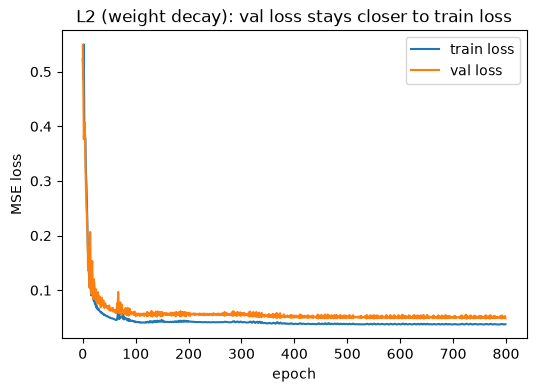

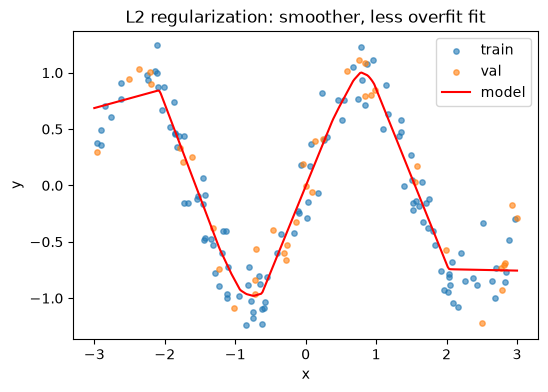

Final train loss: 0.0379 | val loss: 0.0487


In [26]:
l2_model = BigNet()
l2_train, l2_val = train_model(l2_model, epochs=800, lr=0.01, weight_decay=1e-2)

plot_losses(l2_train, l2_val, "L2 (weight decay): val loss stays closer to train loss")
plot_fit(l2_model, "L2 regularization: smoother, less overfit fit")
print(f"Final train loss: {l2_train[-1]:.4f} | val loss: {l2_val[-1]:.4f}")

## 8. Fix #3 — L1 Regularization

L1 regularization penalizes the *absolute* value of weights, which tends to
push many weights toward exactly zero (a sparsifying effect). PyTorch has no
built-in `weight_decay`-style L1 flag, so we add the penalty to the loss
manually inside the training loop (see `l1_lambda` in `train_model`).

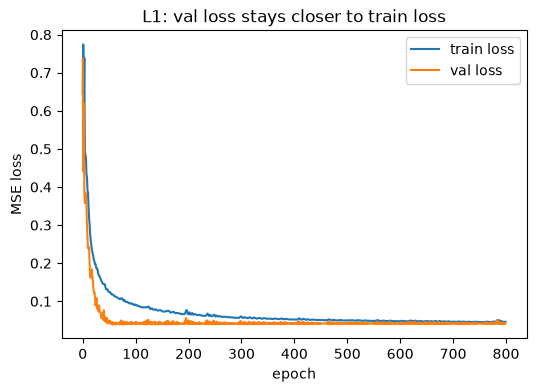

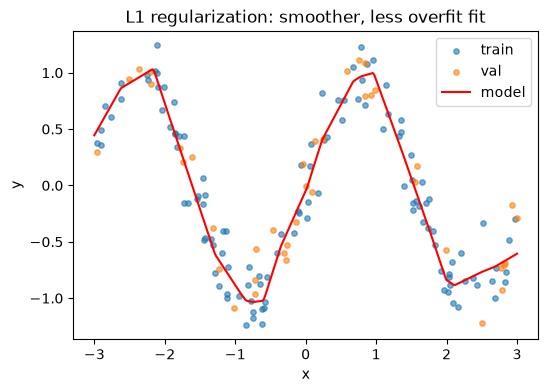

Final train loss: 0.0461 | val loss: 0.0429


In [27]:
l1_model = BigNet()
l1_train, l1_val = train_model(l1_model, epochs=800, lr=0.01, l1_lambda=1e-4)

plot_losses(l1_train, l1_val, "L1: val loss stays closer to train loss")
plot_fit(l1_model, "L1 regularization: smoother, less overfit fit")
print(f"Final train loss: {l1_train[-1]:.4f} | val loss: {l1_val[-1]:.4f}")

## 9. Summary

Compare the final validation loss (lower and closer to train loss is better)
across every model trained in this notebook.

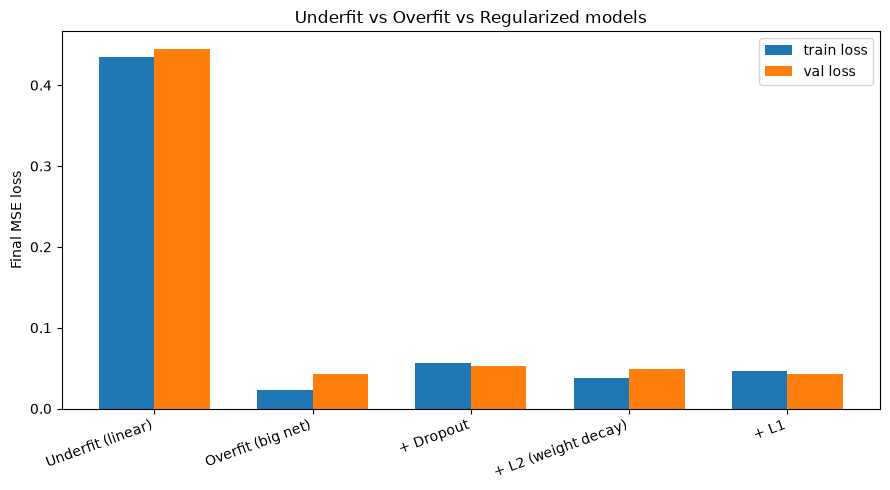

Underfit (linear)      | train: 0.4343 | val: 0.4444 | gap: 0.0101
Overfit (big net)      | train: 0.0231 | val: 0.0431 | gap: 0.0201
+ Dropout              | train: 0.0559 | val: 0.0524 | gap: -0.0035
+ L2 (weight decay)    | train: 0.0379 | val: 0.0487 | gap: 0.0109
+ L1                   | train: 0.0461 | val: 0.0429 | gap: -0.0031


In [28]:
results = {
    "Underfit (linear)": (underfit_train[-1], underfit_val[-1]),
    "Overfit (big net)": (overfit_train[-1], overfit_val[-1]),
    "+ Dropout": (dropout_train[-1], dropout_val[-1]),
    "+ L2 (weight decay)": (l2_train[-1], l2_val[-1]),
    "+ L1": (l1_train[-1], l1_val[-1]),
}

names = list(results.keys())
train_final = [results[n][0] for n in names]
val_final = [results[n][1] for n in names]

x_pos = np.arange(len(names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x_pos - width / 2, train_final, width, label="train loss")
plt.bar(x_pos + width / 2, val_final, width, label="val loss")
plt.xticks(x_pos, names, rotation=20, ha="right")
plt.ylabel("Final MSE loss")
plt.title("Underfit vs Overfit vs Regularized models")
plt.legend()
plt.tight_layout()
plt.show()

for name, (tr, va) in results.items():
    print(f"{name:22s} | train: {tr:.4f} | val: {va:.4f} | gap: {va - tr:.4f}")

## Takeaways

- **Underfitting**: model capacity too low relative to problem complexity →
  high error on *both* train and validation sets. Fix: increase model
  capacity, add features, train longer.
- **Overfitting**: model capacity too high relative to the amount of data →
  low train error, high validation error (large train/val gap). Fix: more
  data, simpler model, or regularization.
- **Dropout**, **L2 (weight decay)**, and **L1** all narrow the train/val gap
  by constraining what the network can memorize — at some cost to training
  loss, in exchange for better generalization.
- Always evaluate using a held-out **validation** set (or k-fold CV for small
  datasets) — the training loss alone cannot tell you whether a model
  overfits.